# OPEN ADDRESSING EXAMPLE

## LINEAR PROBING

In [97]:
class HashTable:
    #Build the builder method
    def __init__(self, size): 
        self.size = size
        self.table = [None] * size
        

    def hash_function(self, key):
        #Basic Hash Function using modulo operation
        return key % self.size
    
    def insert (self, key, value):
        #Find initial index using the hash function
        idx = self.hash_function(key)

        counter = 0
        save = True
        
        #Linear probing to find an available slot
        while self.table[idx] is not None:
            #infinite cycle prevention variable
            counter +=1

            #If not none, must search the next slot
            idx = (idx + 1) % self.size
            if counter > self.size:
                print("No empty slots were found along the hash table, value didn't saved")
                save = False
                break
            

        #insert the key-value pair 
        if save==True:
            self.table[idx] = (key, value)
        

    def search (self, key):
        idx = self.hash_function(key)
        counter = 0

        while self.table[idx] is not None and counter<=self.size:
            #infinite cycle prevention variable
            counter +=1
            if self.table[idx][0] == key:
                return self.table[idx][1]
            else: counter+=1
            
            idx = (idx+1) % self.size # Define next step
        
        print("Value not found")
        return None #This statement is reached only when none value was found and returned in the while loop.
    

    def delete(self, key):
        idx = self.hash_function(key)
        counter = 0

        while self.table[idx] is not None and counter <= self.size:
            #infinite cycle prevention variable
            counter +=1
            if self.table[idx][0] == key:
                self.table[idx] = None #Remove the key-value pair
                print("Value correctly deleted")
                return
            else: counter+=1
            
            idx = (idx + 1) % self.size
        
        print("key not found")
    
    

In [113]:
hash_table = HashTable(10)
#Insert directly

hash_table.insert(10,"apple")
hash_table.insert(20,"banana")
hash_table.insert(15,"orange")


hash_table.insert(3,"strawberry")
hash_table.insert(3,"berry") #Insert with linear probing (by collition)

hash_table.insert(9,"mango")

#Insert with linear probing (by collition) This case shows how by the nature of %size it starts againg from the beginning and founds position 2
#9%10(size) = 9(it is the idx), but is not None.
#Adds 1 to the idx and makes the hash function again: (9+1)%10 = 0 (Note it is the begining of the table)
#idx= 0 is not None, so add another 1: 11%10= 1 --> Which is already taken.
#Adds another 1, idx = (11+1)%10 = 12%10=2 --> Which is found as None (Empty slot)
#Takes this slot.
hash_table.insert(9,"mango")

hash_table.insert(27,"Papaya")
hash_table.insert(27,"Lemon") # Linear Probing Applied
hash_table.insert(27,"Watermelon") # Linear Probing Applied

#At this point the table is totatly full.
print(hash_table.table)

#See what happend when inserting a new value
#The insert function must be equipped with anti infine loops when no empty slot.
#In this cases the values aren't saved
hash_table.insert(37,"Tangerine") # Linear Probing Applied

[(10, 'apple'), (20, 'banana'), (9, 'mango'), (3, 'strawberry'), (3, 'berry'), (15, 'orange'), (27, 'Watermelon'), (27, 'Papaya'), (27, 'Lemon'), (9, 'mango')]
No empty slots were found along the hash table, value didn't saved


In [110]:
#Testing Searching
hash_table.search(9)

'mango'

In [114]:
hash_table.delete(27)
print(hash_table.table)
hash_table.delete(3)
print(hash_table.table)


Value correctly deleted
[(10, 'apple'), (20, 'banana'), (9, 'mango'), (3, 'strawberry'), (3, 'berry'), (15, 'orange'), (27, 'Watermelon'), None, (27, 'Lemon'), (9, 'mango')]
Value correctly deleted
[(10, 'apple'), (20, 'banana'), (9, 'mango'), None, (3, 'berry'), (15, 'orange'), (27, 'Watermelon'), None, (27, 'Lemon'), (9, 'mango')]


___
## DOUBLE HASHING

In [178]:
class HashTableDoubleHashing:
    #Build the builder method
    def __init__(self, size, verbose): 
        self.size = size
        self.table = [None] * size
        self.load_factor = 0
        self.load_counter = 0
        self.verbose = verbose
        

    def hash_function(self, key):
        #Basic Hash Function using modulo operation
        return key % self.size
    
    def secondary_hash_function(self, key):
        prime = self.size-1 
        return prime - (key%prime)

    def insert (self, key, value):
        #Find initial index using the hash function
        idx = self.hash_function(key)
        step_size = self.secondary_hash_function(key)
        #print(step_size)
        counter = 0
        save = True
        

        #Linear probing to find an available slot
        while self.table[idx] is not None:
            #infinite cycle prevention variable
            counter +=1

            #If not none, must search the next slot
            idx = (idx + step_size) % self.size
            if counter > self.size:
                if self.verbose == True: print("No empty slots were found along the hash table, value didn't saved")
                save = False
                break
            

        #insert the key-value pair 
        if save==True:
            self.table[idx] = (key, value)
            self.load_counter +=1
            self.load_factor = self.load_counter/self.size
        

    def search (self, key):
        idx = self.hash_function(key)
        step_size = self.secondary_hash_function(key)
        counter = 0

        while self.table[idx] is not None and counter<=self.size:
            #infinite cycle prevention variable
            counter +=1
            if self.table[idx][0] == key:
                return self.table[idx][1]
            else: counter+=1
            
            idx = (idx+step_size) % self.size # Define next step
        
        if self.verbose == True: print("Value not found")
        return None #This statement is reached only when none value was found and returned in the while loop.
    

    def delete(self, key):
        idx = self.hash_function(key)
        step_size = self.secondary_hash_function(key)
        counter = 0

        while self.table[idx] is not None and counter <= self.size:
            #infinite cycle prevention variable
            counter +=1
            if self.table[idx][0] == key:
                self.table[idx] = None #Remove the key-value pair
                if self.verbose == True: print("Value correctly deleted")
                return
            else: counter+=1
            
            idx = (idx + step_size) % self.size
        
        if self.verbose == True: print("key not found")
    
    

In [122]:
hash_table = HashTableDoubleHashing(10)
#Insert directly

hash_table.insert(10,"apple")
hash_table.insert(20,"banana")
hash_table.insert(15,"orange")


hash_table.insert(3,"strawberry")
hash_table.insert(3,"berry") #Insert with linear probing (by collition)

hash_table.insert(9,"mango")

#Insert with linear probing (by collition) This case shows how by the nature of %size it starts againg from the beginning and founds position 2
#9%10(size) = 9(it is the idx), but is not None.
#Adds 1 to the idx and makes the hash function again: (9+1)%10 = 0 (Note it is the begining of the table)
#idx= 0 is not None, so add another 1: 11%10= 1 --> Which is already taken.
#Adds another 1, idx = (11+1)%10 = 12%10=2 --> Which is found as None (Empty slot)
#Takes this slot.
hash_table.insert(9,"mango")

hash_table.insert(27,"Papaya")
hash_table.insert(27,"Lemon") # Linear Probing Applied
hash_table.insert(27,"Watermelon") # Linear Probing Applied

#At this point the table is totatly full.
print(hash_table.table)

#See what happend when inserting a new value
#The insert function must be equipped with anti infine loops when no empty slot.
#In this cases the values aren't saved
hash_table.insert(37,"Tangerine") # Linear Probing Applied

8
7
3
6
6
9
9
9
9
9
[(10, 'apple'), (27, 'Watermelon'), (27, 'Lemon'), (3, 'strawberry'), (27, 'Papaya'), (15, 'orange'), (9, 'mango'), (20, 'banana'), (9, 'mango'), (3, 'berry')]
8
No empty slots were found along the hash table, value didn't saved


___
# Time Complexity Analysis

In [129]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

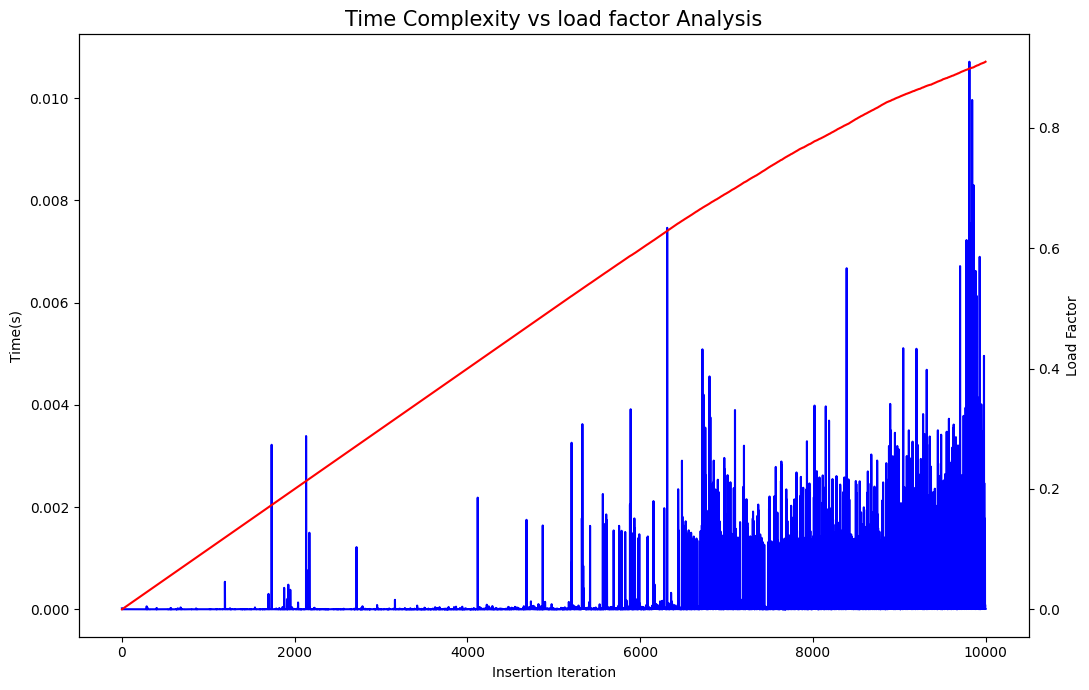

In [181]:
hash_table = HashTableDoubleHashing(10000, False)
#Insert directly

list_Times, list_load_factor =  list(), list()

for _ in range(10000):
    first_Time = time.time()
    hash_table.insert(random.randint(0,1000),"Testing Value")
    second_time= time.time()
    list_Times.append(second_time-first_Time)
    list_load_factor.append(hash_table.load_factor)

fig, ax1 = plt.subplots(figsize=(11,7))
ax1.plot(np.arange(1,10001), list_Times, label="Time", color = 'blue')
ax1.set_xlabel('Insertion Iteration')
ax1.set_ylabel('Time(s)')
ax2 = ax1.twinx()
ax2.plot(np.arange(1,10001), list_load_factor, label='Load Factor', color='red')
ax2.set_ylabel('Load Factor')
plt.title('Time Complexity vs load factor Analysis', fontsize=15)
plt.tight_layout()
plt.show()

1000